<a href="https://colab.research.google.com/github/nightlurkr/FinalProjectAI-CekFresh/blob/main/fp_ai_kel8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"004-Mey Rosalina","key":"KGAT_c72d57b3d662d424756ccef6ad3dbb7d"}'}

In [2]:
import os

os.makedirs('/root/.kaggle', exist_ok=True)
os.rename('kaggle.json', '/root/.kaggle/kaggle.json')

os.chmod('/root/.kaggle/kaggle.json', 600)

print("Kaggle API siap digunakan!")

Kaggle API siap digunakan!


In [3]:
# Download dataset 1: sriramr (pisang & jeruk)
!kaggle datasets download -d sriramr/fruits-fresh-and-rotten-for-classification -p /content/datasets/sriramr

# Download dataset 2: raghavrpotdar (tomat)
!kaggle datasets download -d raghavrpotdar/fresh-and-stale-images-of-fruits-and-vegetables -p /content/datasets/raghavrpotdar

print("Download selesai!")

Dataset URL: https://www.kaggle.com/datasets/sriramr/fruits-fresh-and-rotten-for-classification
License(s): unknown
100% 3.58G/3.58G [00:31<00:00, 123MB/s]

Dataset URL: https://www.kaggle.com/datasets/raghavrpotdar/fresh-and-stale-images-of-fruits-and-vegetables
License(s): CC0-1.0
100% 1.41G/1.41G [00:10<00:00, 138MB/s]

Download selesai!


In [4]:
import zipfile

with zipfile.ZipFile('/content/datasets/sriramr/fruits-fresh-and-rotten-for-classification.zip', 'r') as z:
    z.extractall('/content/datasets/sriramr/')

with zipfile.ZipFile('/content/datasets/raghavrpotdar/fresh-and-stale-images-of-fruits-and-vegetables.zip', 'r') as z:
    z.extractall('/content/datasets/raghavrpotdar/')

print("Ekstrak selesai!")

Ekstrak selesai!


In [5]:
# Melihat isi folder hasil ekstrak untuk memastikan strukturnya benar
for dataset in ['sriramr', 'raghavrpotdar']:
    print(f"\n=== Struktur {dataset} ===")
    for root, dirs, files in os.walk(f'/content/datasets/{dataset}'):
        level = root.replace(f'/content/datasets/{dataset}', '').count(os.sep)
        if level < 3:
            indent = ' ' * 2 * level
            print(f'{indent}{os.path.basename(root)}/')


=== Struktur sriramr ===
sriramr/
  dataset/
    dataset/
    train/
    test/

=== Struktur raghavrpotdar ===
raghavrpotdar/
  fresh_capsicum/
  fresh_banana/
  fresh_tomato/
  stale_capsicum/
  stale_bitter_gourd/
  stale_tomato/
  stale_banana/
  fresh_apple/
  fresh_orange/
  stale_apple/
  stale_orange/
  fresh_bitter_gourd/


### EDA (Exploratory Data Analysis)

Melihat struktur lengkap kedua dataset

In [6]:
print("=== ISI DATASET SRIRAMR ===")
for item in sorted(os.listdir('/content/datasets/sriramr')):
    print(f"  {item}")

print("\n=== ISI DATASET RAGHAVRPOTDAR ===")
for item in sorted(os.listdir('/content/datasets/raghavrpotdar')):
    print(f"  {item}")

=== ISI DATASET SRIRAMR ===
  dataset
  fruits-fresh-and-rotten-for-classification.zip

=== ISI DATASET RAGHAVRPOTDAR ===
  ImageLabels.txt
  fresh-and-stale-images-of-fruits-and-vegetables.zip
  fresh_apple
  fresh_banana
  fresh_bitter_gourd
  fresh_capsicum
  fresh_orange
  fresh_tomato
  stale_apple
  stale_banana
  stale_bitter_gourd
  stale_capsicum
  stale_orange
  stale_tomato


untuk Raghavpotdae langsung terlihat struktur foldernya tapi untuk dataset siramr masih ada didalam folder `dataset` jadi selanjutnya mencoba untuk melihat isi dari folder dataset di sriramr.

In [7]:
print("=== ISI FOLDER DATASET/SRIRAMR ===")
for item in sorted(os.listdir('/content/datasets/sriramr/dataset')):
    print(f"  {item}")

=== ISI FOLDER DATASET/SRIRAMR ===
  dataset
  test
  train


masih ada subfolder lagi dan terlihat bahwa sriramr strukturnya `dataset/dataset/train` dan `dataset/dataset/test` selanjutnya melihat satu level lagi untuk melihat isi dari folder train dan test di sriramr.

In [8]:
print("=== ISI FOLDER TRAIN ===")
for item in sorted(os.listdir('/content/datasets/sriramr/dataset/dataset/train')):
    print(f"  {item}")

print("\n=== ISI FOLDER TEST ===")
for item in sorted(os.listdir('/content/datasets/sriramr/dataset/dataset/test')):
    print(f"  {item}")

=== ISI FOLDER TRAIN ===
  freshapples
  freshbanana
  freshoranges
  rottenapples
  rottenbanana
  rottenoranges

=== ISI FOLDER TEST ===
  freshapples
  freshbanana
  freshoranges
  rottenapples
  rottenbanana
  rottenoranges


#### **Menghitung jumlah gambar per kelas di kedua dataset**

ini untuk mendeteksi jika ada class imbalance (ketidakseimbangan jumlah data antar kelas) sebelum proses training.

In [9]:
sriramr_base_train = '/content/datasets/sriramr/dataset/dataset/train'
sriramr_base_test = '/content/datasets/sriramr/dataset/dataset/test'
raghavrpotdar_base = '/content/datasets/raghavrpotdar'

# Folder yang relevan dari masing-masing dataset
sriramr_folders = [
    'freshbanana', 'rottenbanana',
    'freshoranges', 'rottenoranges'
]

raghavrpotdar_folders = [
    'fresh_tomato', 'stale_tomato'
]

print("=== JUMLAH GAMBAR SRIRAMR (Train) ===")
for folder in sriramr_folders:
    path = os.path.join(sriramr_base_train, folder)
    count = len([f for f in os.listdir(path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    print(f"  {folder}: {count} gambar")

print("\n=== JUMLAH GAMBAR SRIRAMR (Test) ===")
for folder in sriramr_folders:
    path = os.path.join(sriramr_base_test, folder)
    count = len([f for f in os.listdir(path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    print(f"  {folder}: {count} gambar")

print("\n=== JUMLAH GAMBAR RAGHAVRPOTDAR ===")
for folder in raghavrpotdar_folders:
    path = os.path.join(raghavrpotdar_base, folder)
    count = len([f for f in os.listdir(path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    print(f"  {folder}: {count} gambar")

=== JUMLAH GAMBAR SRIRAMR (Train) ===
  freshbanana: 1581 gambar
  rottenbanana: 2224 gambar
  freshoranges: 1466 gambar
  rottenoranges: 1595 gambar

=== JUMLAH GAMBAR SRIRAMR (Test) ===
  freshbanana: 381 gambar
  rottenbanana: 530 gambar
  freshoranges: 388 gambar
  rottenoranges: 403 gambar

=== JUMLAH GAMBAR RAGHAVRPOTDAR ===
  fresh_tomato: 981 gambar
  stale_tomato: 982 gambar


Hasil:

Pisang (sriramr):

- Train: fresh 1.581 + rotten 2.224 = 3.805 gambar
- Test: fresh 381 + rotten 530 = 911 gambar
- Total: fresh 1.581 & rotten 2.224, rasio: 71% **(kurang seimbang**)
- Data ini sedikit tidak seimbang karena selisihnya 643 gambar dimana rotten lebih banyak ±40% dari fresh

Jeruk (sriramr):

- Train: fresh 1.466 + rotten 1.595 = 3.061 gambar
- Test: fresh 388 + rotten 403 = 791 gambar
- Total: fresh 1.466 & rotten 1.595, rasio: 91,9% **(hampir seimbang)**

Tomat (raghavrpotdar):

- fresh 981 + stale 982 = 1.963 gambar
- rasio: 99,9% **(sangat seimbang)**

Total keseluruhan: ±10.531 gambar dimana ini adalah jumlah yang sangat cukup untuk fine-tuning MobileNetV2. Lalu karna sriramr sudah punya pembagian train dan test sendiri, sedangkan raghavrpotdar belum maka selanjutnya ini akan ditangani saat split data nanti.


#### **Visualisai Sample Gambar per Kelas**

 ini menampilkan satu gambar secara acak dari masing-masing kelas (fresh banana, rotten banana, fresh orange, rotten orange, fresh tomato, rotten tomato) dalam satu grid 2×3. Yang mana ini bertujuan untuk memverifikasi secara visual bahwa gambar bisa terbaca dengan benar, tidak korup, dan kualitasnya layak untuk digunakan dalam training.

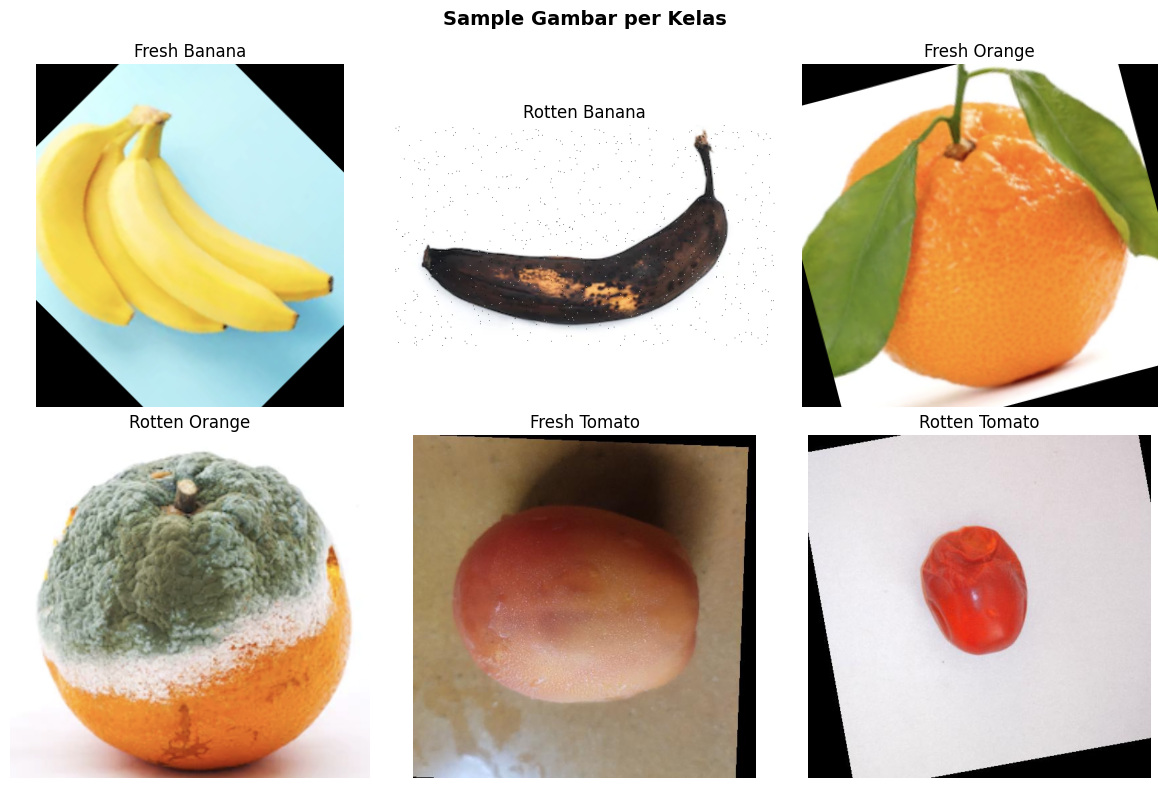

Tampilan sample gambar selesai!


In [10]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

classes = {
    'Fresh Banana'  : '/content/datasets/sriramr/dataset/dataset/train/freshbanana',
    'Rotten Banana' : '/content/datasets/sriramr/dataset/dataset/train/rottenbanana',
    'Fresh Orange'  : '/content/datasets/sriramr/dataset/dataset/train/freshoranges',
    'Rotten Orange' : '/content/datasets/sriramr/dataset/dataset/train/rottenoranges',
    'Fresh Tomato'  : '/content/datasets/raghavrpotdar/fresh_tomato',
    'Rotten Tomato' : '/content/datasets/raghavrpotdar/stale_tomato',
}

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for idx, (label, path) in enumerate(classes.items()):
    images = [f for f in os.listdir(path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    random_img = random.choice(images)

    img = mpimg.imread(os.path.join(path, random_img))
    axes[idx].imshow(img)
    axes[idx].set_title(label, fontsize=12)
    axes[idx].axis('off')

plt.suptitle('Sample Gambar per Kelas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Tampilan sample gambar selesai!")

### Filter, Seleksi & Standarisasi Label

Karena kedua dataset punya struktur dan penamaan folder yang berbeda-beda. Sriramr pakai nama freshbanana, rottenoranges, dll. Raghavrpotdar pakai fresh_tomato, stale_tomato. Maka ini perlu untuk menyatukan semuanya ke dalam satu struktur folder yang seragam dengan label yang konsisten (fresh dan rotten), supaya nanti saat training model tidak bingung membaca datanya.

In [11]:
#membuat struktur folder
import shutil

base_output = '/content/datasets/final'

for split in ['train', 'val', 'test']:
    for label in ['fresh', 'rotten']:
        os.makedirs(f'{base_output}/{split}/{label}', exist_ok=True)

print("Struktur folder final berhasil dibuat!")
print("\nStruktur yang dibuat:")
for split in ['train', 'val', 'test']:
    print(f"  final/{split}/")
    for label in ['fresh', 'rotten']:
        print(f"    {label}/")

Struktur folder final berhasil dibuat!

Struktur yang dibuat:
  final/train/
    fresh/
    rotten/
  final/val/
    fresh/
    rotten/
  final/test/
    fresh/
    rotten/


#### **Mengcopy & standarisasi semua gambar ke folder final:**

In [12]:
import uuid

def copy_images(src_folder, dst_folder):

    images = [f for f in os.listdir(src_folder)
              if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    for img_name in images:
        src_path = os.path.join(src_folder, img_name)
        new_name = f"{uuid.uuid4().hex}.jpg"
        dst_path = os.path.join(dst_folder, new_name)
        shutil.copy2(src_path, dst_path)

    return len(images)

# ============================================================
# SRIRAMR (Pisang & Jeruk)
# Sriramr sudah punya split train dan test sendiri
# Train dari sriramr → akan dimasukkan ke train final
# Test dari sriramr → akan dimasukkan ke test final
# ============================================================

sriramr_train = '/content/datasets/sriramr/dataset/dataset/train'
sriramr_test  = '/content/datasets/sriramr/dataset/dataset/test'

mapping_sriramr_train = {
    'freshbanana'   : 'fresh',
    'rottenbanana'  : 'rotten',
    'freshoranges'  : 'fresh',
    'rottenoranges' : 'rotten',
}

mapping_sriramr_test = {
    'freshbanana'   : 'fresh',
    'rottenbanana'  : 'rotten',
    'freshoranges'  : 'fresh',
    'rottenoranges' : 'rotten',
}

print("=== Menyalin gambar dari SRIRAMR (Train) ===")
for folder, label in mapping_sriramr_train.items():
    src = os.path.join(sriramr_train, folder)
    dst = os.path.join(base_output, 'train', label)
    count = copy_images(src, dst)
    print(f"  {folder} → train/{label}: {count} gambar")

print("\n=== Menyalin gambar dari SRIRAMR (Test) ===")
for folder, label in mapping_sriramr_test.items():
    src = os.path.join(sriramr_test, folder)
    dst = os.path.join(base_output, 'test', label)
    count = copy_images(src, dst)
    print(f"  {folder} → test/{label}: {count} gambar")

# ============================================================
# RAGHAVRPOTDAR (Tomat)
# Raghavrpotdar belum punya split, jadi semua akan dimasukkan
# ke train dulu, nanti akan split manual di step berikutnya
# 'stale' = rotten, lalu standarisasi labelnya
# ============================================================

raghavrpotdar_base = '/content/datasets/raghavrpotdar'

mapping_raghavrpotdar = {
    'fresh_tomato' : 'fresh',
    'stale_tomato' : 'rotten',
}

print("\n=== Menyalin gambar dari RAGHAVRPOTDAR (Tomat) ===")
for folder, label in mapping_raghavrpotdar.items():
    src = os.path.join(raghavrpotdar_base, folder)
    dst = os.path.join(base_output, 'train', label)
    count = copy_images(src, dst)
    print(f"  {folder} → train/{label}: {count} gambar")

print("\nSemua gambar berhasil disalin dan label distandarisasi!")

=== Menyalin gambar dari SRIRAMR (Train) ===
  freshbanana → train/fresh: 1581 gambar
  rottenbanana → train/rotten: 2224 gambar
  freshoranges → train/fresh: 1466 gambar
  rottenoranges → train/rotten: 1595 gambar

=== Menyalin gambar dari SRIRAMR (Test) ===
  freshbanana → test/fresh: 381 gambar
  rottenbanana → test/rotten: 530 gambar
  freshoranges → test/fresh: 388 gambar
  rottenoranges → test/rotten: 403 gambar

=== Menyalin gambar dari RAGHAVRPOTDAR (Tomat) ===
  fresh_tomato → train/fresh: 981 gambar
  stale_tomato → train/rotten: 982 gambar

Semua gambar berhasil disalin dan label distandarisasi!


Jadi ini adalah proses standardisasi label. Fungsi `copy_images` menyalin gambar dari folder sumber ke folder tujuan sekaligus memberi nama file baru yang unik menggunakan UUID, sehingga tidak ada konflik nama antar dataset.

**Mapping label yang dilakukan:**

- freshbanana, freshoranges → fresh
- rottenbanana, rottenoranges, stale_tomato → rotten

Dataset raghavrpotdar (tomat) menggunakan istilah stale untuk busuk, sehingga di sini diubah menjadi rotten agar konsisten.

#### **Mengecek Distribusi Gambar Setelah Proses Copy sebelumnya**

In [13]:
print("=== DISTRIBUSI FOLDER FINAL SAAT INI ===")
total = 0
for split in ['train', 'val', 'test']:
    print(f"\n{split}/")
    for label in ['fresh', 'rotten']:
        path = f'{base_output}/{split}/{label}'
        count = len([f for f in os.listdir(path)
                     if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        print(f"  {label}: {count} gambar")
        total += count

print(f"\nTotal keseluruhan: {total} gambar")

=== DISTRIBUSI FOLDER FINAL SAAT INI ===

train/
  fresh: 4028 gambar
  rotten: 4801 gambar

val/
  fresh: 0 gambar
  rotten: 0 gambar

test/
  fresh: 769 gambar
  rotten: 933 gambar

Total keseluruhan: 10531 gambar


Hasil distribusinya sudah sesuai, tapi disini karena folder val masih kosong jadi ini perlu untuk split sebagian data jadi val dan juga Tomat dari raghavrpotdar belum punya bagian test jadi ini akan ditangani sekalian

#### **Split Data dan Memindahkan Gambar Tomat**

In [14]:
import random
import shutil

def move_images(src_folder, dst_folder, count):

    images = [f for f in os.listdir(src_folder)
              if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    random.seed(42)
    selected = random.sample(images, count)

    for img_name in selected:
        src_path = os.path.join(src_folder, img_name)
        dst_path = os.path.join(dst_folder, img_name)
        shutil.move(src_path, dst_path)

    return count

# ============================================================
# Split:
# Train saat ini: fresh 4028, rotten 4801
# Disini akan mengambil 15% dari train untuk dijadikan val
# fresh : 15% x 4028 = 604 gambar
# rotten: 15% x 4801 = 720 gambar
# ============================================================

val_fresh_count  = int(0.15 * 4028)
val_rotten_count = int(0.15 * 4801)

print("=== Memindahkan gambar dari Train → Val ===")

count = move_images(
    f'{base_output}/train/fresh',
    f'{base_output}/val/fresh',
    val_fresh_count
)
print(f"  train/fresh → val/fresh: {count} gambar dipindahkan")

count = move_images(
    f'{base_output}/train/rotten',
    f'{base_output}/val/rotten',
    val_rotten_count
)
print(f"  train/rotten → val/rotten: {count} gambar dipindahkan")

# ============================================================
# Tomat dari raghavrpotdar belum punya bagian test
# Jadi akan mengambil 15% dari tomat yang ada di train untuk test
# Total tomat di train: fresh 981 + rotten 982
# 15% x 981 = 147, 15% x 982 = 147
# ============================================================

print("\n=== Memindahkan sebagian Tomat dari Train → Test ===")

# Tapi karena tomat sudah tercampur dengan buah lain di folder train
# jadi pakai jumlah proporsional (±147 gambar per kelas)
tomato_test_count = int(0.15 * 981)

count = move_images(
    f'{base_output}/train/fresh',
    f'{base_output}/test/fresh',
    tomato_test_count
)
print(f"  train/fresh → test/fresh (tomat): {count} gambar dipindahkan")

count = move_images(
    f'{base_output}/train/rotten',
    f'{base_output}/test/rotten',
    tomato_test_count
)
print(f"  train/rotten → test/rotten (tomat): {count} gambar dipindahkan")

print("\nSplit selesai!")

=== Memindahkan gambar dari Train → Val ===
  train/fresh → val/fresh: 604 gambar dipindahkan
  train/rotten → val/rotten: 720 gambar dipindahkan

=== Memindahkan sebagian Tomat dari Train → Test ===
  train/fresh → test/fresh (tomat): 147 gambar dipindahkan
  train/rotten → test/rotten (tomat): 147 gambar dipindahkan

Split selesai!


Jadi ditahap ini itu adalah proses:
1. Membuat validation set dengan mengambil 15% dari data train (±604 gambar fresh, ±720 gambar rotten) dan memindahkannya ke folder val/.
2. Membuat test set untuk tomat, karena dataset raghavrpotdar tidak memiliki split test bawaan, kita ambil 15% dari data tomat di train (±147 gambar per kelas) dan dipindahkan ke folder test/.

#### **Mengecek Distribusi Final Dataset**

In [15]:
print("=== DISTRIBUSI FINAL DATASET ===")
total = 0
for split in ['train', 'val', 'test']:
    print(f"\n{split}/")
    split_total = 0
    for label in ['fresh', 'rotten']:
        path = f'{base_output}/{split}/{label}'
        count = len([f for f in os.listdir(path)
                     if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        print(f"  {label}: {count} gambar")
        total += count
        split_total += count
    print(f"  Subtotal: {split_total} gambar")

print(f"\nTotal keseluruhan: {total} gambar")

=== DISTRIBUSI FINAL DATASET ===

train/
  fresh: 3277 gambar
  rotten: 3934 gambar
  Subtotal: 7211 gambar

val/
  fresh: 604 gambar
  rotten: 720 gambar
  Subtotal: 1324 gambar

test/
  fresh: 916 gambar
  rotten: 1080 gambar
  Subtotal: 1996 gambar

Total keseluruhan: 10531 gambar


Dataset final terdiri dari 10.531 gambar yang telah dibagi menjadi tiga split: **train (7.211)**, **val (1.324)**, dan **test (1.996)**

### Preprocessing

#### **Resize, Normalisasi & Augmentasi**

- Resize → MobileNetV2 hanya menerima input gambar ukuran 224×224 dan gambar dari dataset yang ada itu punya ukuran yang berbeda-beda, jadi harus diseragamkan
- Normalisasi → pixel value asli gambar berkisar 0–255, jadi akan diubah ke 0–1 agar model lebih mudah dan cepat belajar
- Augmentasi → khusus data train, akan ditambah variasi gambar secara artifisial (flip, rotasi, brightness) agar model lebih robust dan tidak overfitting

#### **Konfigurasi ImageDataGenerator**

In [16]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Augmentasi hanya diterapkan ke train, bukan val dan test
# karena val dan test digunakan untuk evaluasi kondisi nyata
train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    rotation_range=15,
    brightness_range=[0.8, 1.2],
    zoom_range=0.1,
)

val_test_datagen = ImageDataGenerator(
    rescale=1./255
)

print("ImageDataGenerator berhasil dikonfigurasi!")

ImageDataGenerator berhasil dikonfigurasi!


- **train_datagen** (untuk training) selain normalisasi pixel ke rentang 0–1, juga menerapkan augmentasi data: flip horizontal, rotasi ±15°, variasi kecerahan 80–120%, dan zoom 10%. Augmentasi ini membuat model lebih robust dengan melihat variasi gambar yang lebih beragam.
- **val_test_datagen** (untuk validasi & test) hanya normalisasi saja, tanpa augmentasi. Ini penting agar evaluasi dilakukan pada kondisi gambar yang natural/asli.

#### **Load dataset menggunakan generator**

In [17]:
IMG_SIZE  = (224, 224)
BATCH_SIZE = 32

train_generator = train_datagen.flow_from_directory(
    f'{base_output}/train',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True,
    seed=42
)

val_generator = val_test_datagen.flow_from_directory(
    f'{base_output}/val',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False,
    seed=42
)

test_generator = val_test_datagen.flow_from_directory(
    f'{base_output}/test',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False,
    seed=42
)

print(f"\nClass indices: {train_generator.class_indices}")
print(f"  → Label 'fresh' = {train_generator.class_indices['fresh']}")
print(f"  → Label 'rotten' = {train_generator.class_indices['rotten']}")

Found 7211 images belonging to 2 classes.
Found 1324 images belonging to 2 classes.
Found 1996 images belonging to 2 classes.

Class indices: {'fresh': 0, 'rotten': 1}
  → Label 'fresh' = 0
  → Label 'rotten' = 1


Jadi ini adalah proses yang menghubungkan generator ke folder dataset. Ukuran gambar di resize otomatis ke 224×224 piksel sesuai standar input MobileNetV2. class_mode='binary' digunakan karena hanya ada 2 kelas (fresh = 0, rotten = 1). Generator train di shuffle tiap epoch, sedangkan val dan test tidak perlu diacak karena hanya untuk evaluasi.

dari hasil output:
- Fresh = 0, Rotten = 1 — label sudah terdefinisi dengan benar
- Jumlah gambar juga sudah sesuai distribusi tadi

#### **Hasil Preprocessing Secara Visual**

=== VERIFIKASI PREPROCESSING ===
Shape batch: (32, 224, 224, 3)
  → 32 gambar, ukuran 224x224, 3 channel (RGB)

Nilai pixel min : 0.0000  (seharusnya mendekati 0)
Nilai pixel max : 1.0000  (seharusnya mendekati 1)

Distribusi label dalam batch ini:
  Fresh  (0): 15 gambar
  Rotten (1): 17 gambar


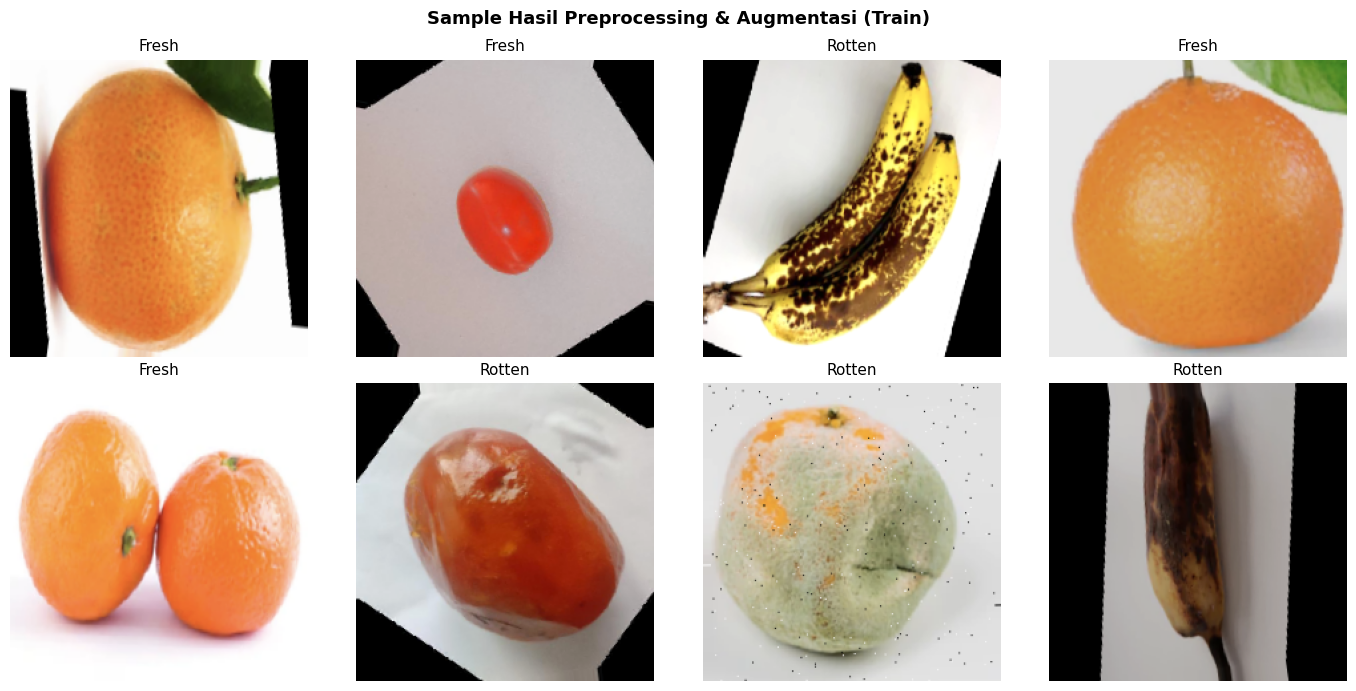

In [18]:
import numpy as np

images, labels = next(train_generator)

print("=== VERIFIKASI PREPROCESSING ===")
print(f"Shape batch: {images.shape}")
print(f"  → {images.shape[0]} gambar, ukuran {images.shape[1]}x{images.shape[2]}, {images.shape[3]} channel (RGB)")
print(f"\nNilai pixel min : {images.min():.4f}  (seharusnya mendekati 0)")
print(f"Nilai pixel max : {images.max():.4f}  (seharusnya mendekati 1)")
print(f"\nDistribusi label dalam batch ini:")
print(f"  Fresh  (0): {(labels == 0).sum()} gambar")
print(f"  Rotten (1): {(labels == 1).sum()} gambar")

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()

label_names = {0: 'Fresh', 1: 'Rotten'}

for i in range(8):
    axes[i].imshow(images[i])
    axes[i].set_title(f"{label_names[labels[i]]}", fontsize=11)
    axes[i].axis('off')

plt.suptitle('Sample Hasil Preprocessing & Augmentasi (Train)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()